# Submission deep-dive (N episodes, one submission)

Purpose: is a symptom **structural or noise**? Exports a noise-floor dict for `submission_comparison.ipynb`.

**Run all cells** — downloads Kaggle replays and builds the summary JSON automatically when needed (cached under `kaggle_logs/`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "experiments"))

import submission_nb as snb
from agent.pricing import MARKET_PARAMS

SUBMISSION_ID = "56575025" # "55938405"  # TwoLand example; change as needed
US_NAME = "Milos Vlainic"  # Kaggle team name (matches info.TeamNames)
REFRESH = False  # True → re-summarize even if JSON exists
DAYS = list(range(snb.SEASON_DAYS))

In [2]:
summary = snb.ensure_summary(
    SUBMISSION_ID, US_NAME, ROOT, refresh=REFRESH, verbose=True
)
games = summary.get("games") or []
agg = summary.get("aggregate") or {}

print(f"submission={summary.get('submission_id')}  n={summary.get('n_episodes')}")
print(f"us_name={summary.get('us_name')}  seat_counts={agg.get('seat_counts')}")
print(f"win_rate={agg.get('win_rate', 0):.3f}")

rows = [snb.episode_row(g) for g in games]
df_ep = pd.DataFrame(rows)
df_ep.head()

Using cached summary /media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/56575025/56575025.json
submission=56575025  n=36
us_name=Milos Vlainic  seat_counts={'0': 19, '1': 17}
win_rate=0.472


,episode_id,seed,reward_us,reward_opp,win,noop_ops,move_overhead,ripe_mean_latency,unexplained_delta,tile_day_utilization,idle_empty,idle_weed,total_hire_spend,days_below_floor,n_steps
0,113637373,0,51253.0,64400.0,False,9,0.735986,33.360190,2884.0,0.555848,10899,1072,368,0,720
1,113638763,798440749,54532.0,111988.0,False,11,0.757179,32.851163,574.0,0.808944,3431,0,360,0,720
2,113639891,830563957,49690.0,63247.0,False,12,0.758469,32.495327,1147.0,0.802667,3519,25,360,0,720
3,113641178,250580357,79950.0,58879.0,True,8,0.704358,44.618375,2495.0,0.773970,6432,49,2998,0,720
4,113642344,751576332,51380.0,90220.0,False,11,0.749383,33.376744,646.0,0.712706,5758,260,368,0,720


## 1. Reward me vs opp (colored by my initial skill) + noise floor

Fetching initialScore for 36 episode(s)...
  episode 113644762: us_skill=509.70885121553914
  episode 113638763: us_skill=600
  episode 113643720: us_skill=454.57467375328696
  episode 113641178: us_skill=403.7138624772619
  episode 113646017: us_skill=469.67380406752795
  episode 113637373: us_skill=None
  episode 113639891: us_skill=485.45228642448706
  episode 113642344: us_skill=514.0750106564103
  episode 113653458: us_skill=484.6752300663888
  episode 113647165: us_skill=513.5264815090568
  episode 113648391: us_skill=478.1702443176721
  episode 113652866: us_skill=506.2970732425166
  episode 113650802: us_skill=485.96328623055604
  episode 113649883: us_skill=513.6404546491103
  episode 113651776: us_skill=508.7515920497917
  episode 113654473: us_skill=524.9587872021583
  episode 113658005: us_skill=538.4095625494962
  episode 113655577: us_skill=543.5347414532273
  episode 113659179: us_skill=523.6807534948774
  episode 113656771: us_skill=521.6002588489505
  episode 113661568

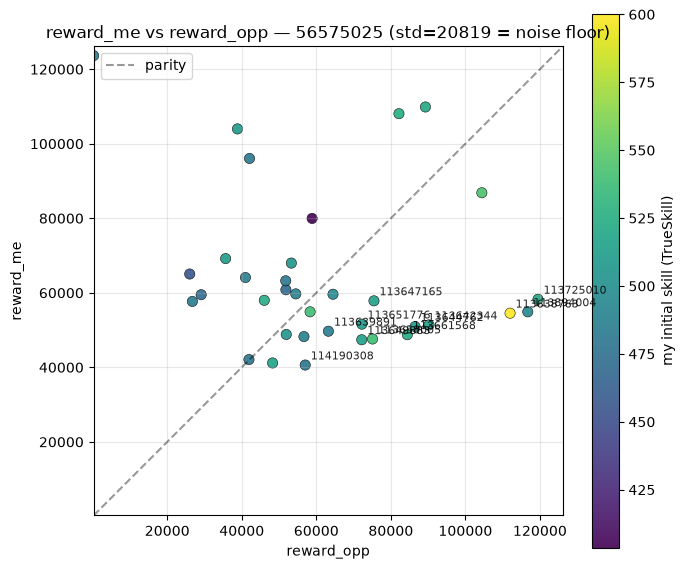

reward_us               20818.874
move_overhead               0.049
noop_ops                    2.567
ripe_mean_latency           6.150
unexplained_delta        1449.495
tile_day_utilization        0.072
total_hire_spend          912.714
days_below_floor            0.000
score_std               20818.874
Name: std_across_episodes, dtype: float64

In [3]:
skills = snb.ensure_episode_skills(SUBMISSION_ID, games, ROOT, refresh=REFRESH)
snb.attach_skills(games, skills)

df_ep = pd.DataFrame([snb.episode_row(g) for g in games])
df_ep["initial_score_us"] = [g.get("initial_score_us") for g in games]
df_ep["initial_score_opp"] = [g.get("initial_score_opp") for g in games]

rewards = df_ep["reward_us"].dropna().astype(float)
score_std = float(rewards.std()) if len(rewards) > 1 else 0.0
noise_floor = snb.noise_floor_from_games(games)
noise_floor["score_std"] = score_std

print(f"mean={rewards.mean():.0f}  median={rewards.median():.0f}  std={score_std:.0f}")
print(f"win_rate={df_ep['win'].mean():.3f}")

scatter = df_ep.dropna(subset=["reward_us", "reward_opp", "initial_score_us"])
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    scatter["reward_opp"],
    scatter["reward_us"],
    c=scatter["initial_score_us"],
    cmap="viridis",
    s=55,
    edgecolors="k",
    linewidths=0.4,
    alpha=0.9,
)


cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("my initial skill (TrueSkill)")
cbar.ax.set_zorder(0)
ax.set_zorder(1)
ax.patch.set_zorder(-1)

lim_hi = float(max(scatter["reward_us"].max(), scatter["reward_opp"].max())) * 1.02
lim_lo = float(min(scatter["reward_us"].min(), scatter["reward_opp"].min())) * 0.98
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], "k--", alpha=0.4, label="parity")
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_xlabel("reward_opp")
ax.set_ylabel("reward_me")
ax.set_title(
    f"reward_me vs reward_opp — {SUBMISSION_ID} "
    f"(std={score_std:.0f} = noise floor)"
)
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

bad = scatter[
    (scatter["reward_opp"] > 0)
    & (scatter["reward_us"] / scatter["reward_opp"] < 0.8)
]
for _, row in bad.iterrows():
    ax.annotate(
        str(row["episode_id"]),
        (row["reward_opp"], row["reward_us"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
        alpha=0.85,
        zorder=10,
        clip_on=False,
    )
plt.tight_layout()
plt.show()

pd.Series(noise_floor, name="std_across_episodes").round(3)


## 2. Day-banded series (mean ± std)

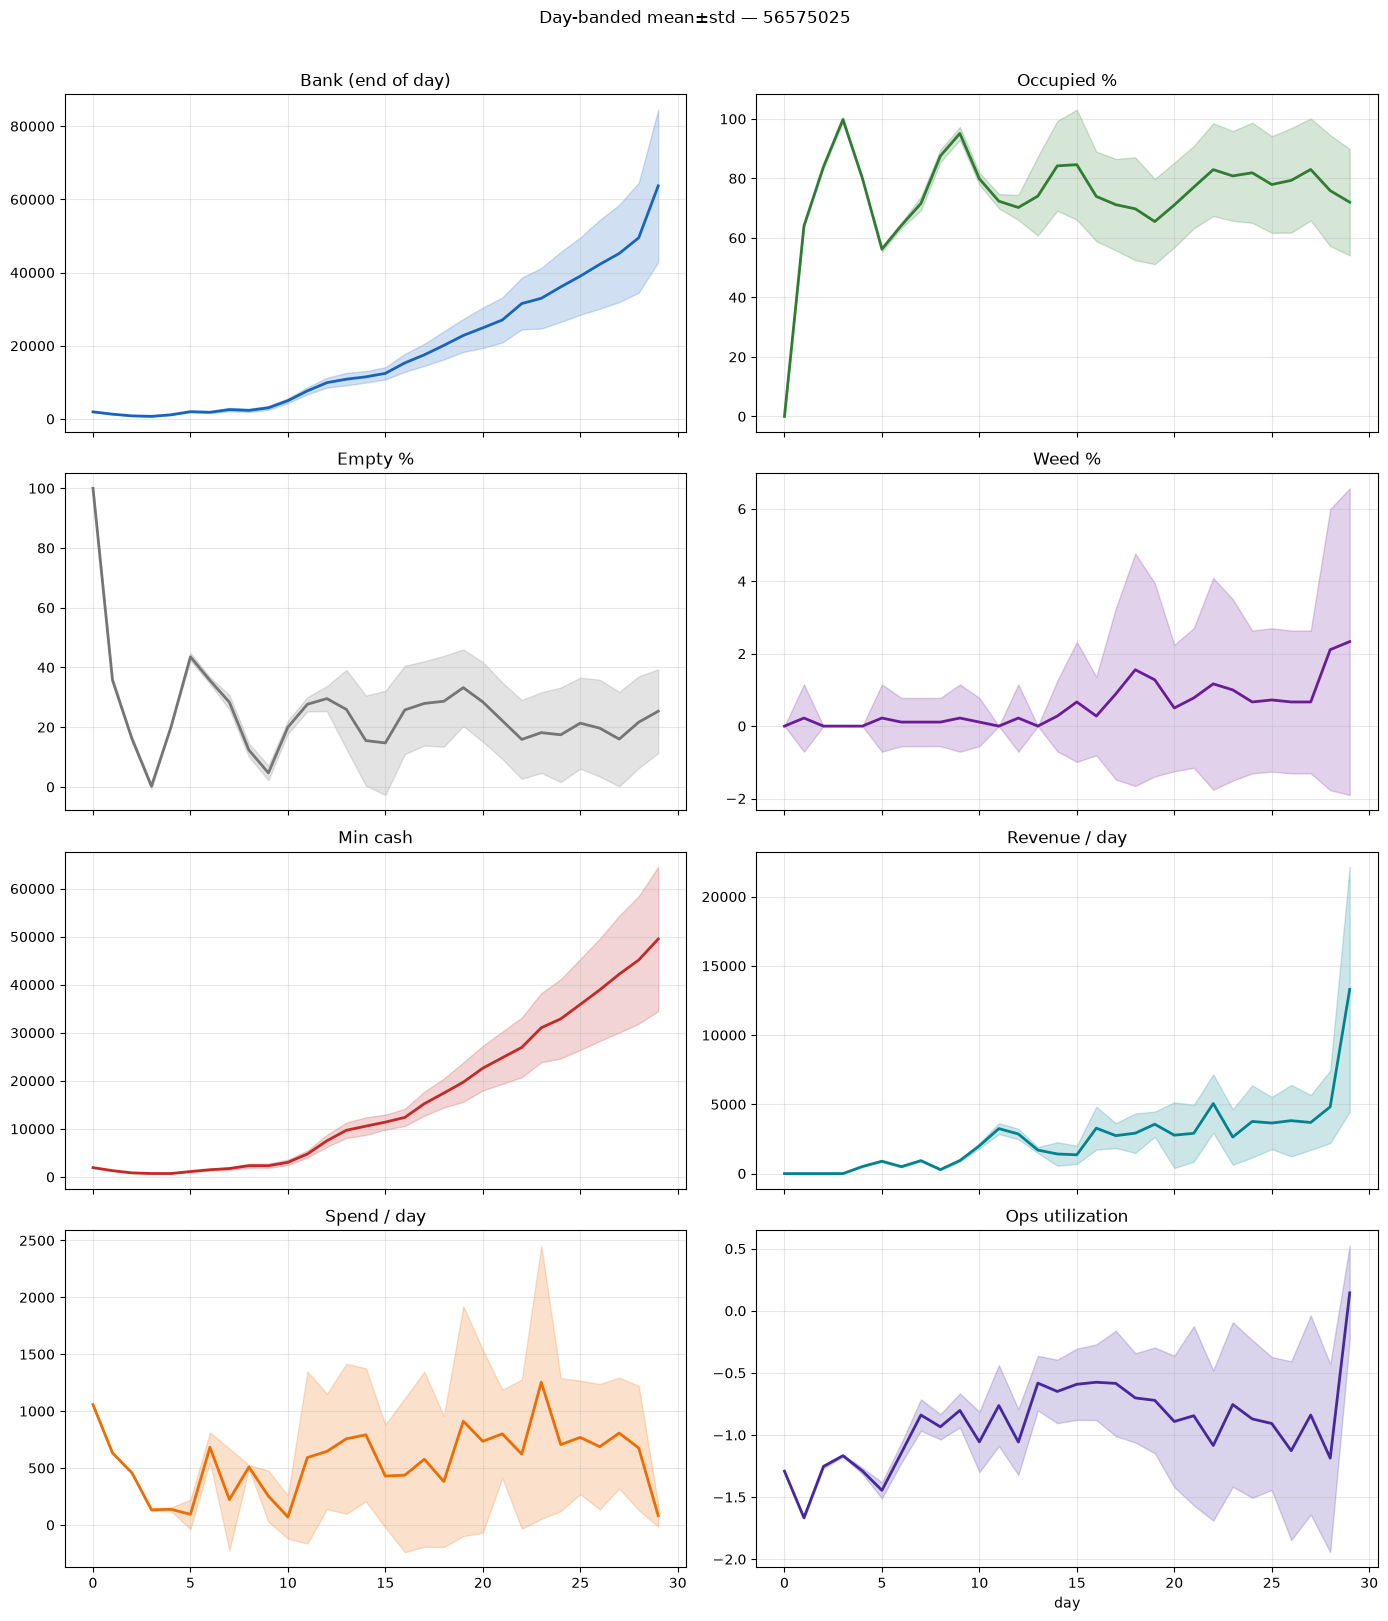

In [4]:
series_specs = [
    ("Bank (end of day)", snb.bank_end_series, "#1565c0"),
    ("Occupied %", snb.occupied_pct_series, "#2e7d32"),
    ("Empty %", lambda g: snb.tile_pct_series(g, "empty"), "#757575"),
    ("Weed %", lambda g: snb.tile_pct_series(g, "weed"), "#6a1b9a"),
    ("Min cash", snb.min_cash_series, "#c62828"),
    ("Revenue / day", snb.revenue_series, "#00838f"),
    ("Spend / day", snb.spend_series, "#ef6c00"),
    ("Ops utilization", snb.ops_util_series, "#4527a0"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.ravel()
for ax, (title, fn, color) in zip(axes, series_specs):
    mean, std = snb.day_band(games, fn)
    m = np.array(mean, dtype=float)
    s = np.array(std, dtype=float)
    ax.plot(DAYS, m, color=color, lw=2)
    ax.fill_between(DAYS, m - s, m + s, color=color, alpha=0.2)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
fig.suptitle(f"Day-banded mean±std — {SUBMISSION_ID}", y=1.01)
plt.tight_layout()
plt.show()

## 3. KPI boxplots across episodes

/tmp/ipykernel_1013232/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_1013232/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_1013232/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_1013232/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)


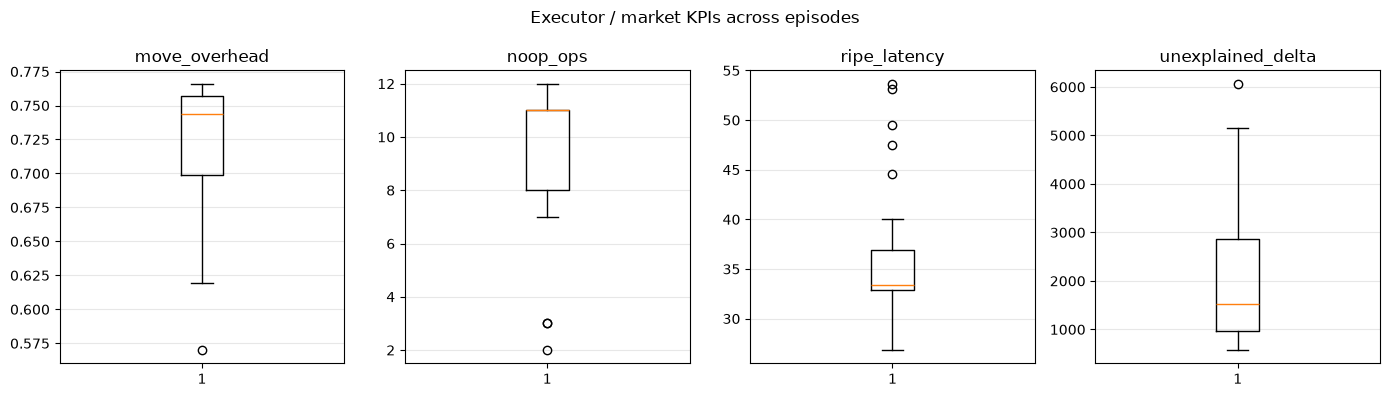

In [5]:
scalar_kpis = [
    ("move_overhead", df_ep["move_overhead"]),
    ("noop_ops", df_ep["noop_ops"]),
    ("ripe_latency", df_ep["ripe_mean_latency"]),
    ("unexplained_delta", df_ep["unexplained_delta"]),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (label, vals) in zip(axes, scalar_kpis):
    ax.boxplot(vals.dropna(), vert=True)
    ax.set_title(label)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Executor / market KPIs across episodes")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1013232/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
/tmp/ipykernel_1013232/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)


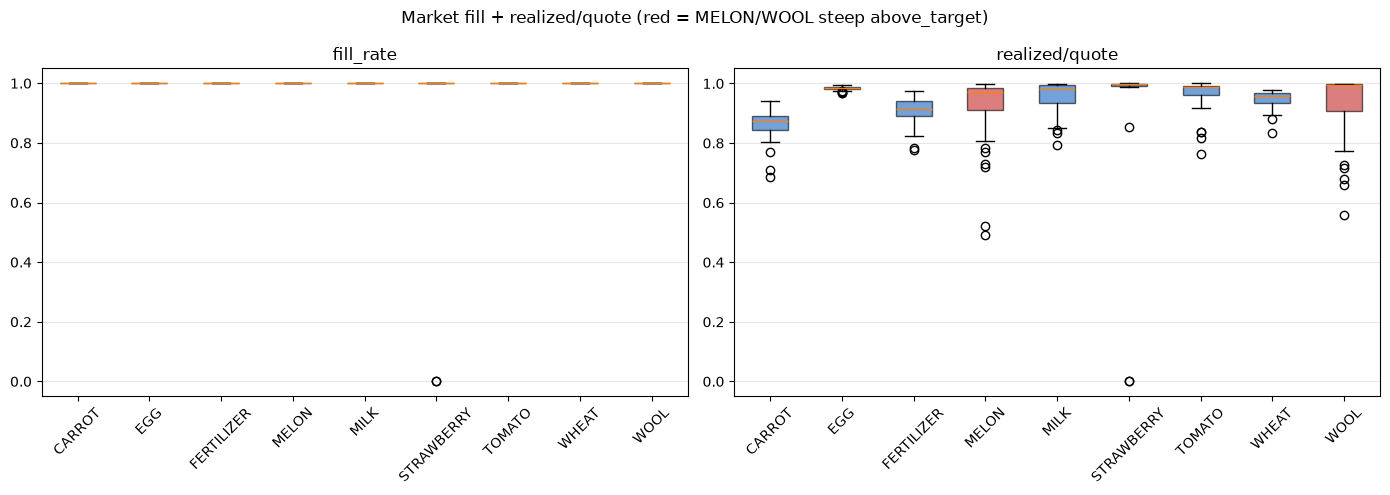

fill_rate      realized_vs_quote          
             mean  std              mean       std
product                                           
MELON         1.0  0.0          0.912952  0.126398
WOOL          1.0  0.0          0.924624  0.119846

In [6]:
# Fill rate + realized/quote per product (MELON & WOOL highlighted)
products = sorted({p for g in games for p in (snb.us_kpi(g)[1].get("fill_rate") or {})})
fill_rows = []
for g in games:
    eid = g.get("episode_id")
    for prod in products:
        fill_rows.append({
            "episode_id": eid,
            "product": prod,
            "fill_rate": snb.fill_rate_for(g, prod),
            "realized_vs_quote": snb.realized_quote_for(g, prod),
            "steep_glut": prod in snb.STEEP_GLUT_PRODUCTS,
            "above_target": getattr(MARKET_PARAMS.get(prod), "above_target", None),
        })
df_fill = pd.DataFrame(fill_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylab in zip(axes, ["fill_rate", "realized_vs_quote"], ["fill_rate", "realized/quote"]):
    data = []
    labels = []
    colors = []
    for prod in products:
        sub = df_fill[df_fill["product"] == prod][col].dropna()
        if len(sub):
            data.append(sub.values)
            labels.append(prod)
            colors.append("#c62828" if prod in snb.STEEP_GLUT_PRODUCTS else "#1565c0")
    bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax.set_title(ylab)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Market fill + realized/quote (red = MELON/WOOL steep above_target)")
plt.tight_layout()
plt.show()

df_fill[df_fill["steep_glut"]].groupby("product")[["fill_rate", "realized_vs_quote"]].agg(["mean", "std"])

## 4. Land-purchase timing

,episode_id,seed,day,quadrant,cost,cash_before,cash_after,days_below_floor,reward_us,win
1,113641178,250580357,12,NE,1000,6866.0,6882.0,0,79950.0,True
4,113647165,971772899,12,NE,1000,6486.0,8082.0,0,57845.0,False
7,113653458,2088561985,12,NE,1000,6676.0,8028.0,0,57687.0,True
10,113656771,1811497660,12,NE,1000,6730.0,8418.0,0,109862.0,True
11,113658005,374493906,12,NE,1000,6135.0,7613.0,0,47612.0,False
20,113970857,549031305,12,NE,1000,6150.0,7755.0,0,123647.0,True
18,113820414,905340992,13,NE,1000,9200.0,8280.0,0,48824.0,False
3,113644762,889262965,14,NE,1000,10953.0,10711.0,0,50942.0,False
8,113654473,1793222471,14,NE,1000,9743.0,9783.0,0,108066.0,True
17,113815831,1112496547,14,NE,1000,11087.0,9097.0,0,41174.0,False


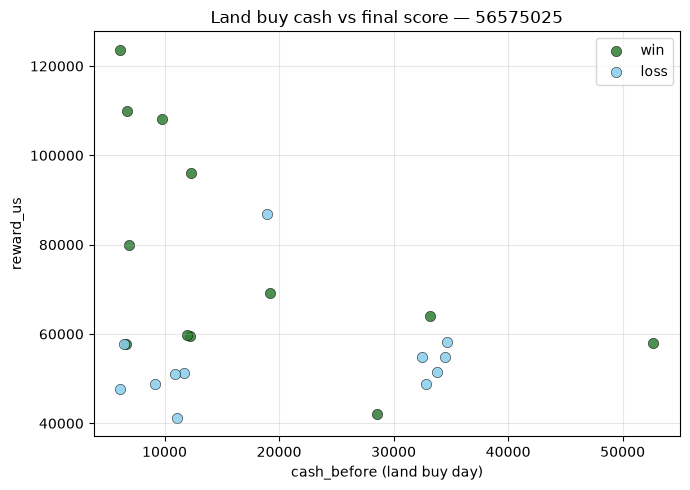

In [7]:
land_rows = []
for g in games:
    land_rows.extend(snb.land_purchase_rows(g))
df_land = pd.DataFrame(land_rows)
if df_land.empty:
    print("No land_events in this submission.")
else:
    display(df_land.sort_values(["day", "episode_id"]))

    plot_df = df_land.dropna(subset=["cash_before", "reward_us", "win"])
    fig, ax = plt.subplots(figsize=(7, 5))
    for won, color, label in [(True, "#2e7d32", "win"), (False, "skyblue", "loss")]:
        sub = plot_df[plot_df["win"] == won]
        if sub.empty:
            continue
        ax.scatter(
            sub["cash_before"],
            sub["reward_us"],
            c=color,
            s=55,
            edgecolors="k",
            linewidths=0.4,
            alpha=0.85,
            label=label,
        )
    ax.set_xlabel("cash_before (land buy day)")
    ax.set_ylabel("reward_us")
    ax.set_title(f"Land buy cash vs final score — {SUBMISSION_ID}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5. Anomaly table

In [8]:
df_anom = pd.DataFrame(snb.anomaly_rows(games))
if df_anom.empty:
    print("No anomalies flagged.")
else:
    display(df_anom)

NOISE_FLOOR = noise_floor
print(f"\nNOISE_FLOOR ready (score_std={NOISE_FLOOR.get('score_std', 0):.0f})")

No anomalies flagged.

NOISE_FLOOR ready (score_std=20819)
